In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(pd.__version__)
print(np.__version__)

3.0.3
2.4.6


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option("display.max_columns", None)

print("Setup Complete")

Setup Complete


# Load Datasets

In [3]:
customers = pd.read_csv("../data/customers.csv")

orders = pd.read_csv("../data/orders.csv")

tickets = pd.read_csv("../data/support_tickets.csv")

web = pd.read_csv("../data/web_events_snapshot.csv")

campaigns = pd.read_csv("../data/intervention_history.csv")

churn = pd.read_csv("../data/churn_labels.csv")

# Dataset Overview

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "campaigns": campaigns,
    "churn": churn
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (2400, 9)
orders: (10009, 10)
tickets: (1921, 8)
web: (2400, 10)
campaigns: (2400, 5)
churn: (2400, 4)


# Convert Dates

In [5]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)

tickets["ticket_date"] = pd.to_datetime(
    tickets["ticket_date"]
)

# Leakage Prevention

In [6]:
# Create
snapshot_date = pd.Timestamp("2025-09-30")

# Filter
orders_pre = orders[
    orders["order_date"] <= snapshot_date
].copy()

# Check
print("Original Orders :", len(orders))
print("Pre Snapshot Orders :", len(orders_pre))

Original Orders : 10009
Pre Snapshot Orders : 8137


## 5. RFM Feature Engineering

RFM analysis is used to understand customer purchasing behaviour.

- Recency: Days since last purchase
- Frequency: Number of orders placed
- Monetary: Total spend before snapshot date

Only pre-snapshot orders are used to avoid data leakage.

In [7]:
# Last order date per customer
# Recency
last_order = (
    orders_pre.groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

last_order["recency"] = (
    snapshot_date - last_order["order_date"]
).dt.days

last_order.head()

,customer_id,order_date,recency
0,CUST00001,2025-06-15,107
1,CUST00002,2025-08-21,40
2,CUST00003,2025-04-12,171
3,CUST00004,2025-05-22,131
4,CUST00005,2025-08-23,38


In [8]:
frequency = (
    orders_pre.groupby("customer_id")["order_id"]
    .count()
    .reset_index()
)

frequency.rename(
    columns={"order_id": "frequency"},
    inplace=True
)

frequency.head()

,customer_id,frequency
0,CUST00001,6
1,CUST00002,1
2,CUST00003,1
3,CUST00004,1
4,CUST00005,4


In [9]:
monetary = (
    orders_pre.groupby("customer_id")["gross_amount"]
    .sum()
    .reset_index()
)

monetary.rename(
    columns={"gross_amount": "monetary"},
    inplace=True
)

monetary.head()

,customer_id,monetary
0,CUST00001,2955.57
1,CUST00002,581.00
2,CUST00003,649.98
3,CUST00004,1604.04
4,CUST00005,2550.91


In [10]:
rfm = (
    last_order[["customer_id", "recency"]]
    .merge(frequency, on="customer_id")
    .merge(monetary, on="customer_id")
)

rfm.head()

,customer_id,recency,frequency,monetary
0,CUST00001,107,6,2955.57
1,CUST00002,40,1,581.00
2,CUST00003,171,1,649.98
3,CUST00004,131,1,1604.04
4,CUST00005,38,4,2550.91


In [11]:
# Validate RFM
print("Rows:", len(rfm))
print()

print(rfm.describe())

Rows: 2400

           recency    frequency      monetary
count  2400.000000  2400.000000   2400.000000
mean     87.375833     3.390417   2549.655729
std      80.137473     2.383350   2129.104340
min       0.000000     1.000000    149.000000
25%      25.000000     1.000000    955.380000
50%      66.000000     3.000000   2012.020000
75%     129.000000     5.000000   3566.080000
max     562.000000    16.000000  27215.920000


In [12]:
# Missing Values Check
rfm.isnull().sum()

customer_id    0
recency        0
frequency      0
monetary       0
dtype: int64

In [13]:
# Save RFM Summary
rfm.to_csv(
    "../outputs/rfm_summary.csv",
    index=False
)

print("RFM Summary Saved")

RFM Summary Saved


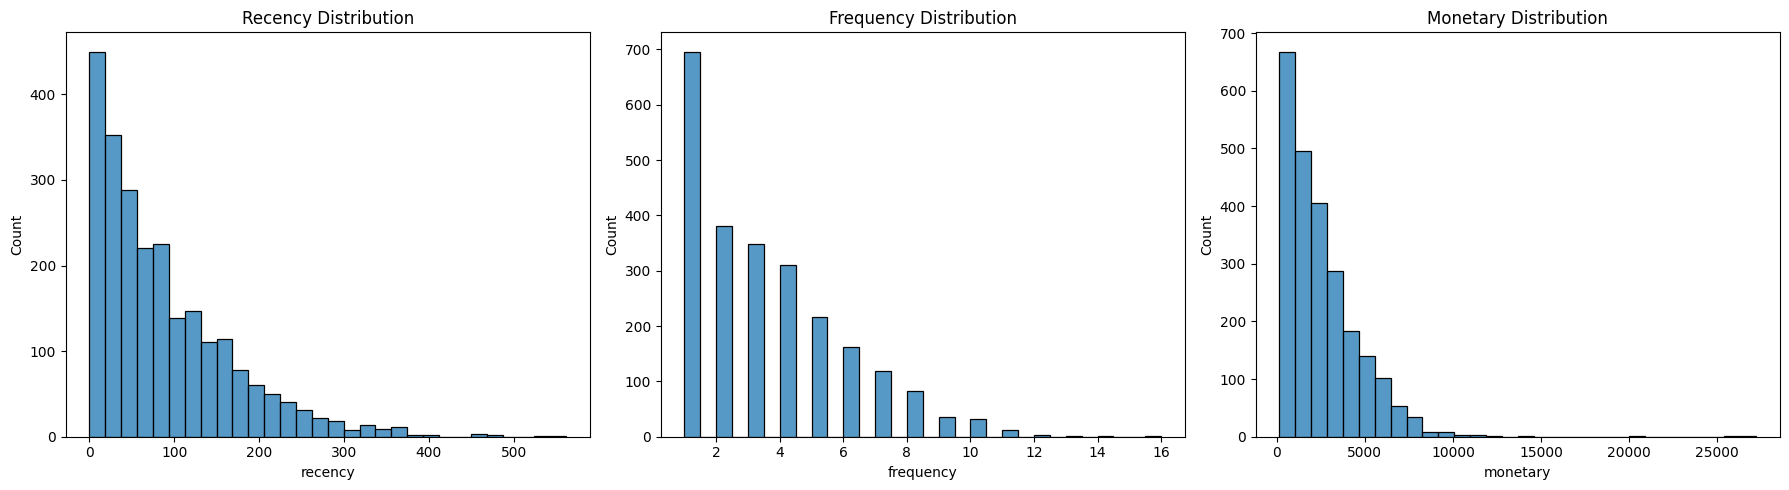

In [14]:
# RFM Distributions
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(
    rfm["recency"],
    bins=30,
    ax=axes[0]
)

axes[0].set_title("Recency Distribution")

sns.histplot(
    rfm["frequency"],
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Frequency Distribution")

sns.histplot(
    rfm["monetary"],
    bins=30,
    ax=axes[2]
)

axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.savefig(
    "../outputs/charts/rfm_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Additional Behavioral Signals

To improve customer understanding, RFM features are combined with behavioral and support indicators.

Additional signals include:

- Return Rate
- Discount Usage
- Support Ticket Activity
- Customer Sentiment
- Website/App Engagement
- Campaign Interaction

These features help identify customers who may appear valuable based on spending alone but exhibit dissatisfaction or disengagement.

In [15]:
# Return Rate
return_rate = (
    orders_pre.groupby("customer_id")["returned"]
    .mean()
    .reset_index()
)

return_rate.rename(
    columns={"returned":"return_rate"},
    inplace=True
)

return_rate.head()

,customer_id,return_rate
0,CUST00001,0.166667
1,CUST00002,0.000000
2,CUST00003,0.000000
3,CUST00004,0.000000
4,CUST00005,0.000000


In [16]:
# Average Discount Usage
discount_usage = (
    orders_pre.groupby("customer_id")["discount_pct"]
    .mean()
    .reset_index()
)

discount_usage.rename(
    columns={
        "discount_pct":"avg_discount"
    },
    inplace=True
)

discount_usage.head()

,customer_id,avg_discount
0,CUST00001,0.363333
1,CUST00002,0.230000
2,CUST00003,0.470000
3,CUST00004,0.160000
4,CUST00005,0.442500


In [17]:
# Category Diversity
category_diversity = (
    orders_pre.groupby("customer_id")["category"]
    .nunique()
    .reset_index()
)

category_diversity.rename(
    columns={
        "category":"category_diversity"
    },
    inplace=True
)

category_diversity.head()

,customer_id,category_diversity
0,CUST00001,3
1,CUST00002,1
2,CUST00003,1
3,CUST00004,1
4,CUST00005,2


In [18]:
# Ticket Count
ticket_count = (
    tickets.groupby("customer_id")["ticket_id"]
    .count()
    .reset_index()
)

ticket_count.rename(
    columns={
        "ticket_id":"ticket_count"
    },
    inplace=True
)

ticket_count.head()

,customer_id,ticket_count
0,CUST00001,2
1,CUST00002,1
2,CUST00005,1
3,CUST00006,2
4,CUST00008,1


In [19]:
# Average Sentiment
sentiment = (
    tickets.groupby("customer_id")["sentiment_score"]
    .mean()
    .reset_index()
)

sentiment.rename(
    columns={
        "sentiment_score":"avg_sentiment"
    },
    inplace=True
)

sentiment.head()

,customer_id,avg_sentiment
0,CUST00001,0.14
1,CUST00002,0.00
2,CUST00005,-1.00
3,CUST00006,-0.68
4,CUST00008,0.08


In [20]:
# Average Resolution Time
resolution = (
    tickets.groupby("customer_id")
    ["resolution_hours"]
    .mean()
    .reset_index()
)

resolution.rename(
    columns={
        "resolution_hours":
        "avg_resolution_hours"
    },
    inplace=True
)

resolution.head()

,customer_id,avg_resolution_hours
0,CUST00001,4.35
1,CUST00002,1.00
2,CUST00005,37.70
3,CUST00006,17.60
4,CUST00008,6.00


In [21]:
# Customer Master Table
master = customers.copy()
master = (
    master
    .merge(rfm,on="customer_id",how="left")
    .merge(return_rate,on="customer_id",how="left")
    .merge(discount_usage,on="customer_id",how="left")
    .merge(category_diversity,on="customer_id",how="left")
    .merge(ticket_count,on="customer_id",how="left")
    .merge(sentiment,on="customer_id",how="left")
    .merge(resolution,on="customer_id",how="left")
    .merge(web,on="customer_id",how="left")
    .merge(campaigns,on="customer_id",how="left")
    .merge(churn,on="customer_id",how="left")
)

In [22]:
# Fill Missing Values
master["ticket_count"] = (
    master["ticket_count"]
    .fillna(0)
)

master["avg_sentiment"] = (
    master["avg_sentiment"]
    .fillna(0)
)

master["avg_resolution_hours"] = (
    master["avg_resolution_hours"]
    .fillna(0)
)
master["loyalty_tier"] = (
    master["loyalty_tier"]
    .fillna("Not Enrolled")
)

master["skin_type"] = (
    master["skin_type"]
    .fillna("Unknown")
)
master[
    ["loyalty_tier","skin_type"]
].isnull().sum()

loyalty_tier    0
skin_type       0
dtype: int64

In [23]:
# Validation
print(master.shape)
master.isnull().sum().sort_values(
    ascending=False
).head(20)

(2400, 34)


customer_id             0
signup_date             0
city_tier               0
age_group               0
acquisition_channel     0
loyalty_tier            0
preferred_category      0
skin_type               0
marketing_consent       0
recency                 0
frequency               0
monetary                0
return_rate             0
avg_discount            0
category_diversity      0
ticket_count            0
avg_sentiment           0
avg_resolution_hours    0
snapshot_date_x         0
sessions_30d            0
dtype: int64

In [24]:
# Save Customer Master
master.to_csv(
    "../outputs/customer_master.csv",
    index=False
)

print("Customer Master Saved")

Customer Master Saved


## 7. RFM Scoring

Customers are scored from 1–5 for:

- Recency
- Frequency
- Monetary Value

Higher scores indicate more valuable customers.

In [25]:
# Recency Score
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5,4,3,2,1]
)

In [26]:
# Frequency Score
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

In [27]:
# Monetary Score
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1,2,3,4,5]
)

In [28]:
# Convert to Integer
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

In [29]:
# Create Combined Score
rfm["RFM_SCORE"] = (
    rfm["R_score"].astype(str)
    +
    rfm["F_score"].astype(str)
    +
    rfm["M_score"].astype(str)
)

In [30]:
# Validate
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_SCORE
0,CUST00001,107,6,2955.57,2,5,4,254
1,CUST00002,40,1,581.00,4,1,1,411
2,CUST00003,171,1,649.98,1,1,1,111
3,CUST00004,131,1,1604.04,2,1,3,213
4,CUST00005,38,4,2550.91,4,3,3,433


In [31]:
# Check Score distribution
rfm[
    [
        "R_score",
        "F_score",
        "M_score"
    ]
].describe()

,R_score,F_score,M_score
count,2400.000000,2400.000000,2400.000000
mean,3.012500,3.000000,3.000000
std,1.422095,1.414508,1.414508
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


In [32]:
# Merge Scores into Master
master = master.merge(
    rfm[
        [
            "customer_id",
            "R_score",
            "F_score",
            "M_score",
            "RFM_SCORE"
        ]
    ],
    on="customer_id",
    how="left"
)

In [33]:
# Verify
master[
    [
        "customer_id",
        "R_score",
        "F_score",
        "M_score",
        "RFM_SCORE"
    ]
].head()

,customer_id,R_score,F_score,M_score,RFM_SCORE
0,CUST00001,2,5,4,254
1,CUST00002,4,1,1,411
2,CUST00003,1,1,1,111
3,CUST00004,2,1,3,213
4,CUST00005,4,3,3,433


## 8. Customer Segmentation

Customer segments were created using RFM scores and behavioural signals.

Additional signals used:

- Return Rate
- Support Ticket Count
- Sentiment Score
- Discount Usage

The objective is to identify customers requiring different retention strategies.

In [34]:
def assign_segment(row):

    # Champions
    if (
        row["R_score"] >= 4
        and row["F_score"] >= 4
        and row["M_score"] >= 4
    ):
        return "Champions"

    # Loyal Customers
    elif (
        row["R_score"] >= 3
        and row["F_score"] >= 4
    ):
        return "Loyal Customers"

    # Potential Loyalists
    elif (
        row["R_score"] >= 4
        and row["F_score"] >= 2
    ):
        return "Potential Loyalists"

    # New Customers
    elif (
        row["R_score"] >= 4
        and row["F_score"] == 1
    ):
        return "New Customers"

    # High Value but Unhappy
    elif (
        row["M_score"] >= 4
        and row["ticket_count"] >= 2
        and row["avg_sentiment"] < 0
    ):
        return "High Value Unhappy"

    # Discount Sensitive
    elif (
        row["avg_discount"] >= 0.35
    ):
        return "Discount Sensitive"

    # Promising
    elif (
        row["R_score"] == 3
        and row["F_score"] >= 2
    ):
        return "Promising"

    # At Risk
    elif (
        row["R_score"] <= 2
        and row["M_score"] >= 3
    ):
        return "At Risk"

    # Dormant
    elif (
        row["R_score"] == 1
        and row["F_score"] <= 2
    ):
        return "Dormant"

    else:
        return "Regular Customers"

## Threshold Justification

Additional behavioral thresholds were selected to improve business relevance.

- avg_discount >= 0.35 identifies customers with high discount dependency.
- ticket_count >= 2 identifies customers requiring repeated support assistance.
- avg_sentiment < 0 identifies customers with negative support experiences.

These thresholds were used to identify High Value Unhappy and Discount Sensitive customers beyond traditional RFM analysis.

In [35]:
master["segment_name"] = (
    master.apply(
        assign_segment,
        axis=1
    )
)

In [36]:
segment_summary = (
    master["segment_name"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    "segment_name",
    "customer_count"
]

segment_summary

,segment_name,customer_count
0,At Risk,389
1,Potential Loyalists,364
2,Champions,344
3,Discount Sensitive,269
4,Loyal Customers,256
5,New Customers,208
6,Regular Customers,199
7,Promising,138
8,Dormant,121
9,High Value Unhappy,112


## Customer Lifecycle Interpretation

The segmentation reflects a practical customer lifecycle:

New Customers
→ Potential Loyalists
→ Loyal Customers
→ Champions

Customers may also move toward churn risk:

Champions
→ High Value Unhappy
→ At Risk
→ Dormant

This lifecycle view helps prioritize retention actions according to customer value and churn risk.

In [37]:
segment_summary.to_csv(
    "../outputs/tables/segment_summary.csv",
    index=False
)

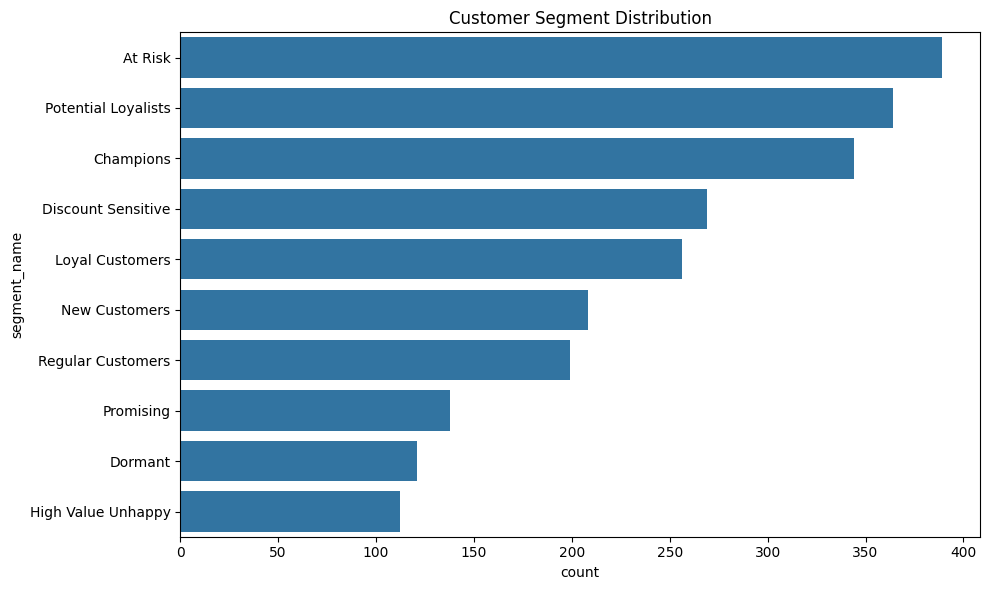

In [38]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=master,
    y="segment_name",
    order=master["segment_name"]
        .value_counts()
        .index
)

plt.title(
    "Customer Segment Distribution"
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

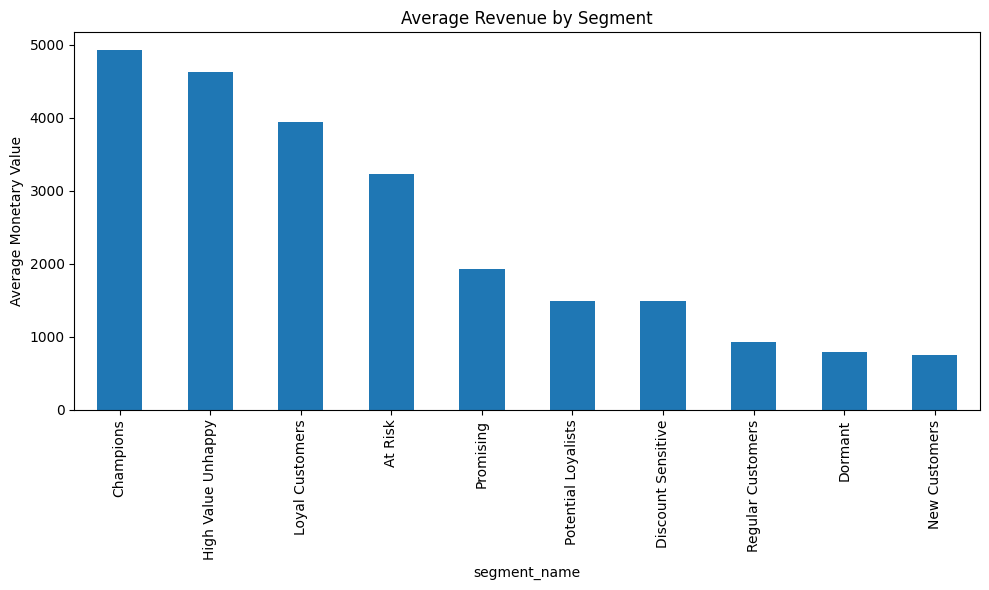

In [39]:
segment_revenue = (
    master.groupby("segment_name")
    ["monetary"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(10,6))

segment_revenue.plot(
    kind="bar"
)

plt.title(
    "Average Revenue by Segment"
)

plt.ylabel(
    "Average Monetary Value"
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/revenue_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

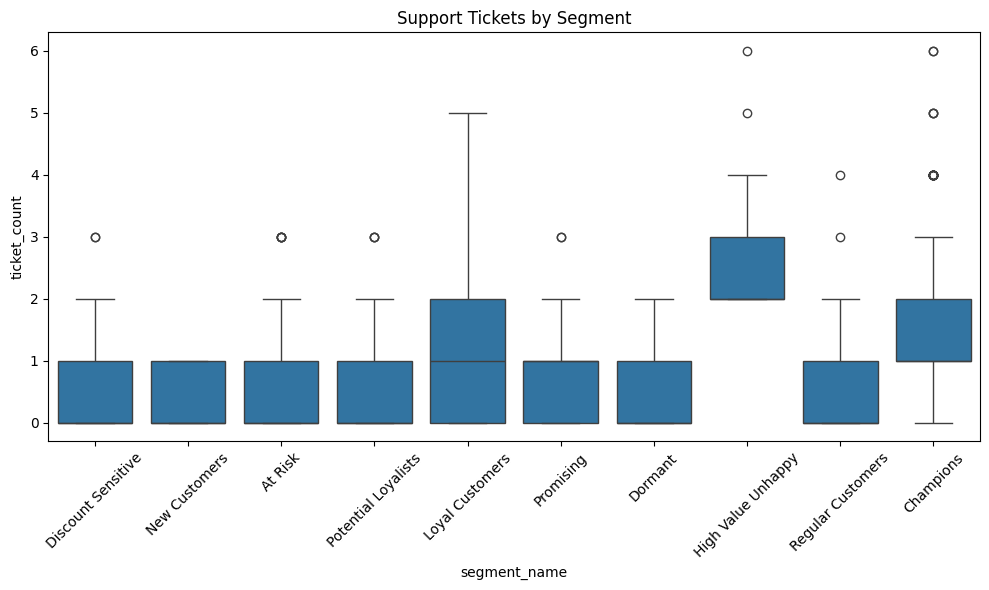

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=master,
    x="segment_name",
    y="ticket_count"
)

plt.xticks(rotation=45)

plt.title(
    "Support Tickets by Segment"
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/tickets_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
segment_kpis = (
    master.groupby("segment_name")
    .agg({
        "recency":"mean",
        "frequency":"mean",
        "monetary":"mean",
        "ticket_count":"mean",
        "return_rate":"mean",
        "avg_discount":"mean"
    })
    .round(2)
)

segment_kpis

,recency,frequency,monetary,ticket_count,return_rate,avg_discount
segment_name,,,,,,
At Risk,163.60,3.94,3233.39,0.60,0.05,0.25
Champions,20.65,6.38,4920.77,1.46,0.07,0.27
Discount Sensitive,140.75,2.31,1484.67,0.53,0.05,0.41
Dormant,221.45,1.21,792.82,0.30,0.05,0.24
High Value Unhappy,148.16,5.93,4625.94,2.50,0.11,0.27
Loyal Customers,57.21,5.50,3939.50,1.31,0.06,0.28
New Customers,19.88,1.00,743.42,0.28,0.11,0.29
Potential Loyalists,20.80,2.06,1489.16,0.47,0.06,0.29
Promising,67.14,2.30,1930.41,0.60,0.08,0.24


In [42]:
segment_kpis.to_csv(
    "../outputs/tables/segment_kpis.csv"
)

In [43]:
segment_churn = (
    master.groupby("segment_name")
    ["churn_next_60d"]
    .mean()
    .sort_values(
        ascending=False
    )
)

segment_churn

segment_name
Dormant                0.900826
At Risk                0.786632
Discount Sensitive     0.747212
Regular Customers      0.738693
High Value Unhappy     0.723214
Promising              0.434783
Loyal Customers        0.277344
New Customers          0.216346
Potential Loyalists    0.195055
Champions              0.104651
Name: churn_next_60d, dtype: float64

## Business Validation

To validate segmentation quality, average churn rates were compared across customer segments.

Results show:

- Champions have the lowest churn rate (10.5%).
- Dormant customers have the highest churn rate (90.1%).
- High Value Unhappy customers exhibit both high revenue and elevated churn risk.

This confirms that the segmentation successfully separates low-risk and high-risk customer groups.

In [44]:
segment_churn.to_csv(
    "../outputs/tables/segment_churn_rate.csv"
)

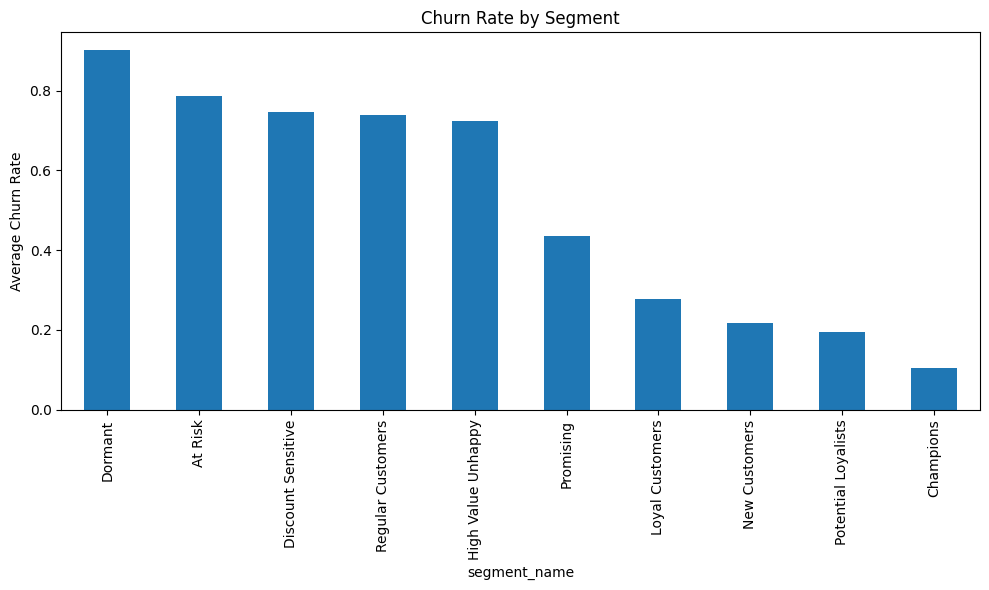

In [45]:
plt.figure(figsize=(10,6))

segment_churn.plot(
    kind="bar"
)

plt.title(
    "Churn Rate by Segment"
)

plt.ylabel(
    "Average Churn Rate"
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/churn_rate_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
segments = master[
    [
        "customer_id",
        "segment_name",
        "recency",
        "frequency",
        "monetary",
        "ticket_count",
        "return_rate",
        "avg_discount",
        "category_diversity",
        "churn_next_60d"
    ]
]

In [47]:
segments.to_csv(
    "../outputs/segments.csv",
    index=False
)

In [48]:
segments.head()

,customer_id,segment_name,recency,frequency,monetary,ticket_count,return_rate,avg_discount,category_diversity,churn_next_60d
0,CUST00001,Discount Sensitive,107,6,2955.57,2.0,0.166667,0.363333,3,1
1,CUST00002,New Customers,40,1,581.00,1.0,0.000000,0.230000,1,0
2,CUST00003,Discount Sensitive,171,1,649.98,0.0,0.000000,0.470000,1,1
3,CUST00004,At Risk,131,1,1604.04,0.0,0.000000,0.160000,1,1
4,CUST00005,Potential Loyalists,38,4,2550.91,1.0,0.000000,0.442500,2,0


In [49]:
manual_review = master[
    (
        (master["M_score"] >= 4)
        &
        (master["ticket_count"] >= 2)
    )
    |
    (
        (master["avg_discount"] >= 0.40)
        &
        (master["frequency"] >= 3)
    )
    |
    (
        (master["R_score"] >= 4)
        &
        (master["F_score"] == 1)
    )
]

manual_review = manual_review.head(20)

In [50]:
manual_review[
    [
        "customer_id",
        "segment_name",
        "recency",
        "frequency",
        "monetary",
        "ticket_count",
        "avg_sentiment",
        "avg_discount"
    ]
]

,customer_id,segment_name,recency,frequency,monetary,ticket_count,avg_sentiment,avg_discount
0,CUST00001,Discount Sensitive,107,6,2955.57,2.0,0.140000,0.363333
1,CUST00002,New Customers,40,1,581.00,1.0,0.000000,0.230000
4,CUST00005,Potential Loyalists,38,4,2550.91,1.0,-1.000000,0.442500
5,CUST00006,Loyal Customers,51,5,3770.16,2.0,-0.680000,0.358000
6,CUST00007,New Customers,3,1,719.33,0.0,0.000000,0.180000
8,CUST00009,New Customers,31,1,376.85,0.0,0.000000,0.490000
9,CUST00010,New Customers,9,1,636.80,0.0,0.000000,0.450000
13,CUST00014,Loyal Customers,51,11,8130.16,2.0,-0.245000,0.261818
21,CUST00022,New Customers,29,1,454.06,0.0,0.000000,0.310000
22,CUST00023,New Customers,21,1,400.98,0.0,0.000000,0.250000


In [52]:
segments = master[
    [
        "customer_id",
        "segment_name",
        "recency",
        "frequency",
        "monetary",
        "ticket_count",
        "return_rate",
        "avg_discount",
        "category_diversity",
        "churn_next_60d"
    ]
]

segments.to_csv(
    "../segments.csv",
    index=False
)

print("segments.csv saved")

segments.csv saved
